In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the first CSV file
df1 = pd.read_csv('online_data.csv')

# Load the second CSV file
df2 = pd.read_csv('offline_data.csv')

# Display the first few rows of each DataFrame
print("First DataFrame:")
print(df1.head())

print("\nSecond DataFrame:")
print(df2.head())

First DataFrame:
               Time         PV        CSP
0  11/21/2025 12:00 -95.111206  21.824137
1  11/21/2025 12:15 -79.040161  21.947670
2  11/21/2025 12:30 -77.619263  22.071203
3  11/21/2025 12:45 -81.562866  22.194735
4  11/21/2025 13:00 -82.373657  22.318268

Second DataFrame:
               Time  Titer
0  11/21/2025 10:26   22.4
1  11/22/2025 11:24   38.1
2   11/23/2025 8:14   69.6
3   11/24/2025 8:55  136.0
4   11/25/2025 8:31  267.4


Updated df1:
                 Time         PV        CSP  Elapsed_Time_Days  PV_Smoothed
0 2025-11-21 12:00:00 -95.111206  21.824137           0.065278          NaN
1 2025-11-21 12:15:00 -79.040161  21.947670           0.075694          NaN
2 2025-11-21 12:30:00 -77.619263  22.071203           0.086111   -83.333374
3 2025-11-21 12:45:00 -81.562866  22.194735           0.096528   -80.148987
4 2025-11-21 13:00:00 -82.373657  22.318268           0.106944   -78.386932

Updated df2:
                 Time  Titer  Elapsed_Time_Days
0 2025-11-21 10:26:00   22.4           0.000000
1 2025-11-22 11:24:00   38.1           1.040278
2 2025-11-23 08:14:00   69.6           1.908333
3 2025-11-24 08:55:00  136.0           2.936806
4 2025-11-25 08:31:00  267.4           3.920139
Smoothed df1:
                 Time         PV        CSP  Elapsed_Time_Days  PV_Smoothed
0 2025-11-21 12:00:00 -95.111206  21.824137           0.065278          NaN
1 2025-11-21 12:15:00 -79.040161  21.947670           0.075694 

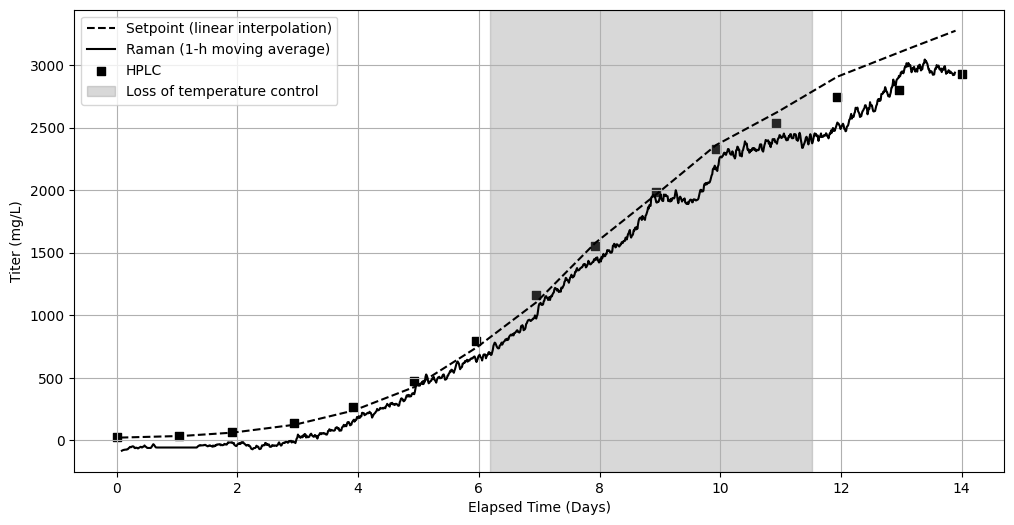

In [22]:
# Convert the Time columns to datetime format
df1['Time'] = pd.to_datetime(df1['Time'])
df2['Time'] = pd.to_datetime(df2['Time'])

# Get the reference time from the first timestamp in df2.Time
reference_time = df2['Time'].iloc[0]

# Calculate the elapsed time in minutes for both DataFrames
df1['Elapsed_Time_Days'] = (df1['Time'] - reference_time).dt.total_seconds() / (60 * 60 * 24)
df2['Elapsed_Time_Days'] = (df2['Time'] - reference_time).dt.total_seconds() / (60 * 60 * 24)

# Display the updated DataFrames
print("Updated df1:")
print(df1.head())

print("\nUpdated df2:")
print(df2.head())

# Smooth df1.PV by a moving average of 1-hour window (4 intervals of 15 minutes each)
df1['PV_Smoothed'] = df1['PV'].rolling(window=4, center=True).mean()

# Display the updated DataFrame
print("Smoothed df1:")
print(df1.head())

# Plot CSP and PV_Smoothed against Elapsed_Time_Days as lines
plt.figure(figsize=(12, 6))
plt.plot(df1['Elapsed_Time_Days'], df1['CSP'], label='Setpoint (linear interpolation)', color='black', linestyle='--')
plt.plot(df1['Elapsed_Time_Days'], df1['PV_Smoothed'], label='Raman (1-h moving average)', color='black', linestyle='-')

# Plot df2.Titer against Elapsed_Time_Days as dots
plt.scatter(df2['Elapsed_Time_Days'], df2['Titer'], label='HPLC', color='black', marker='s')

# Add a transparent shadow rectangle to indicate the period between elapsed time 6 and 11
# Calculate the elapsed times for the given timestamps
timestamp1 = pd.Timestamp('2025-11-27 14:44:00')
timestamp2 = pd.Timestamp('2025-12-02 22:53:00')
elapsed_time1 = (timestamp1 - reference_time).total_seconds() / (60 * 60 * 24)
elapsed_time2 = (timestamp2 - reference_time).total_seconds() / (60 * 60 * 24)
plt.axvspan(elapsed_time1, elapsed_time2, color='gray', alpha=0.3, label='Loss of temperature control')

# Add labels, legend, and title
plt.xlabel('Elapsed Time (Days)')
plt.ylabel('Titer (mg/L)')
# plt.title('CSP, PV Smoothed, and Titer over Elapsed Time')
plt.legend()
plt.grid(True)

# Save the figure as a PNG file in the same folder
plt.savefig('raman.png', format='png', dpi=300)

# Show the plot
plt.show()

